# Iris Flowers Machine Learning Classification Model :

In [1]:
# importing libraries 
import pandas as pd
import numpy as np 
import matplotlib.pylab as plt
import seaborn as sns 
plt.style.use('ggplot')

In [2]:
# loading data
FilePath="../dataset/Iris.csv"
df=pd.read_csv(FilePath)

## Data Exploration :

In [3]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
df.tail()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica
149,150,5.9,3.0,5.1,1.8,Iris-virginica


In [5]:
df.columns

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='str')

In [6]:
df.shape

(150, 6)

In [7]:
df.dtypes

Id                 int64
SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
Species              str
dtype: object

In [8]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [9]:
# identifying the percentage of null values in each column
def nan_perc(df):
    total_cells=np.prod(df.shape)
    total_nan_col=df.isna().sum()
    total_rows=len(df)
    total_nan=sum(total_nan_col)
    print("Total percentage of nan :",(total_nan/total_cells)*100)
    print("Percentage of nan in each column :")
    print((total_nan_col/total_rows)*100)

In [10]:
nan_perc(df)

Total percentage of nan : 0.0
Percentage of nan in each column :
Id               0.0
SepalLengthCm    0.0
SepalWidthCm     0.0
PetalLengthCm    0.0
PetalWidthCm     0.0
Species          0.0
dtype: float64


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
# we will take only columns that will serve us later in the prediction (Id column is not included)
df=df[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species']]

## Data Analysis :

In [13]:
df.columns

Index(['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='str')

### Sepal Length (cm) :

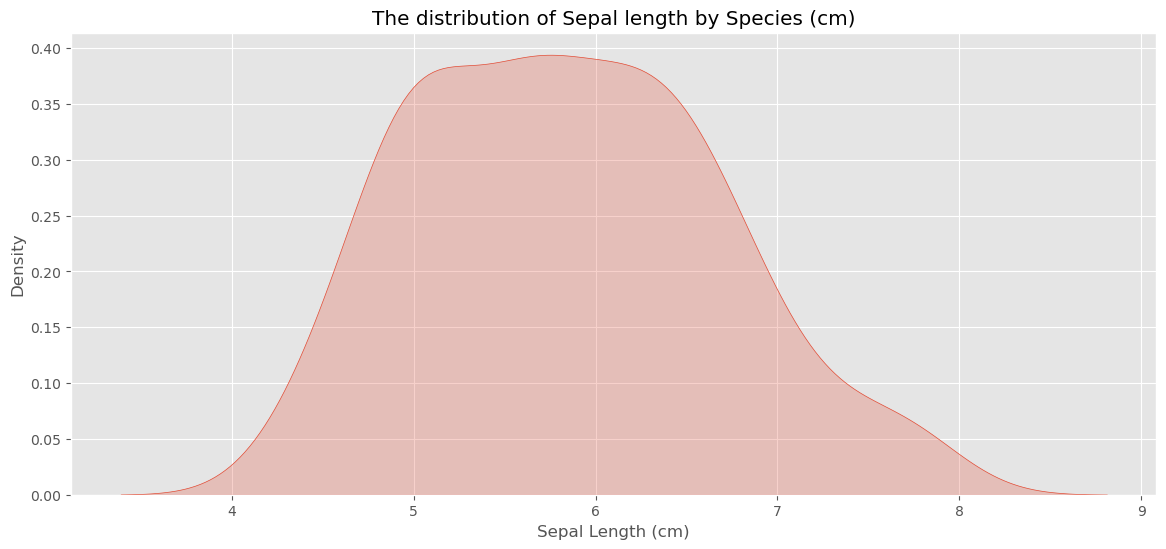

In [14]:
plt.figure(figsize=(14,6))
sns.kdeplot(data=df,x='SepalLengthCm',fill=True)
plt.xlabel('Sepal Length (cm)')
plt.title("The distribution of Sepal length by Species (cm)")
plt.show()

- Sepal length's average is about 6cm and it varies between 4.5cm to 7cm for all species in general

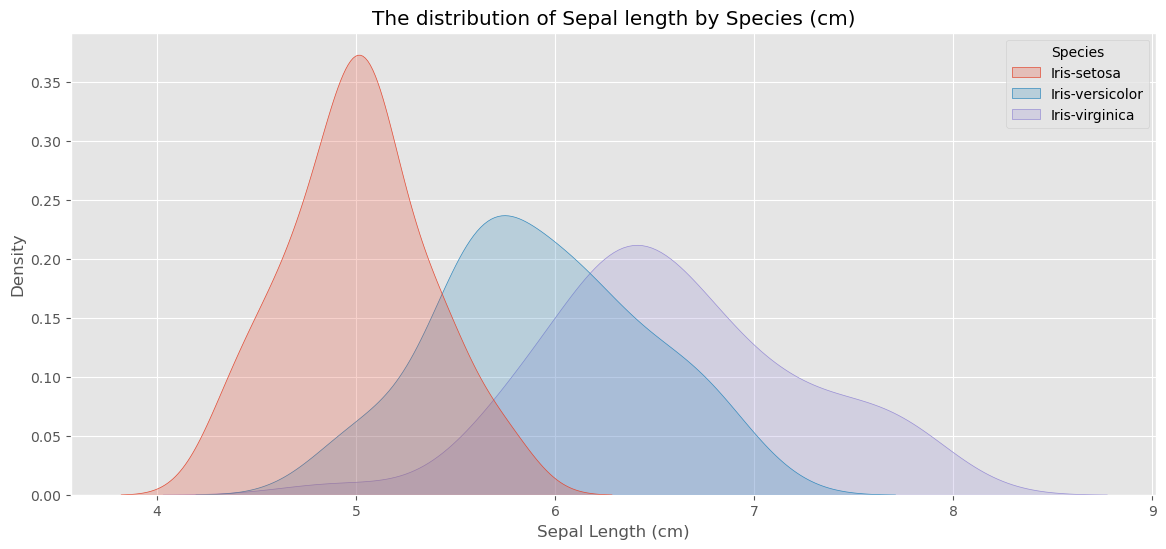

In [15]:
plt.figure(figsize=(14,6))
sns.kdeplot(data=df,x='SepalLengthCm',fill=True,hue='Species')
plt.xlabel('Sepal Length (cm)')
plt.title("The distribution of Sepal length by Species (cm)")
plt.show()

- Setosa Iris's sepals are relatively smller than other species of 5cm length  in average while versicolor and virginica have sepals with length of 5.7cm to 6.5cm length 

### Sepal Width (Cm):

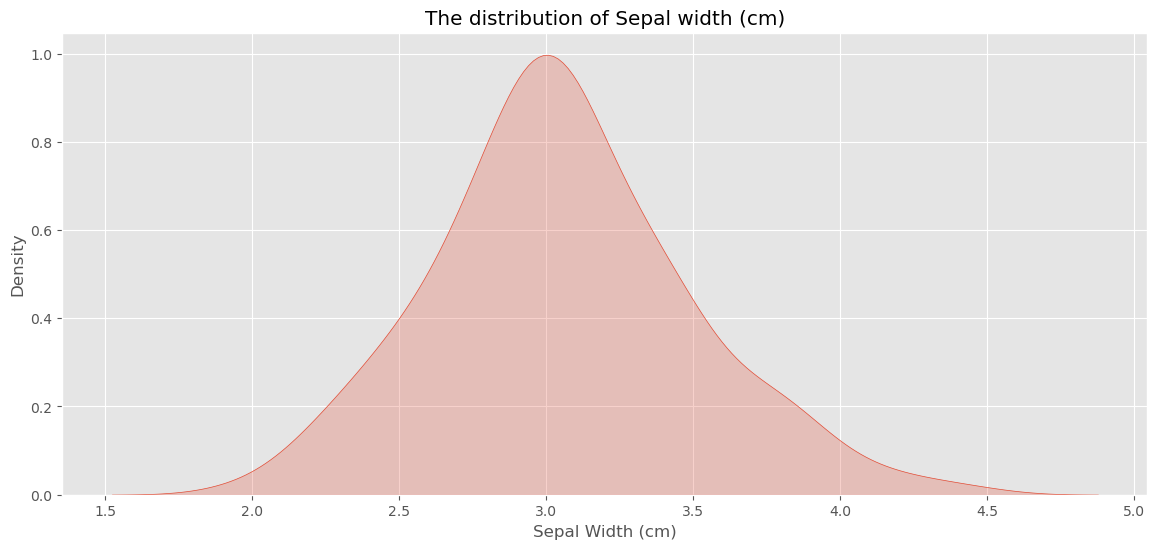

In [16]:
plt.figure(figsize=(14,6))
sns.kdeplot(data=df,x='SepalWidthCm',fill=True)
plt.xlabel('Sepal Width (cm)')
plt.title("The distribution of Sepal width (cm)")
plt.show()

- Sepal width is normally distributed with an average of 3cm and it varies between 2cm to 4.5cm .

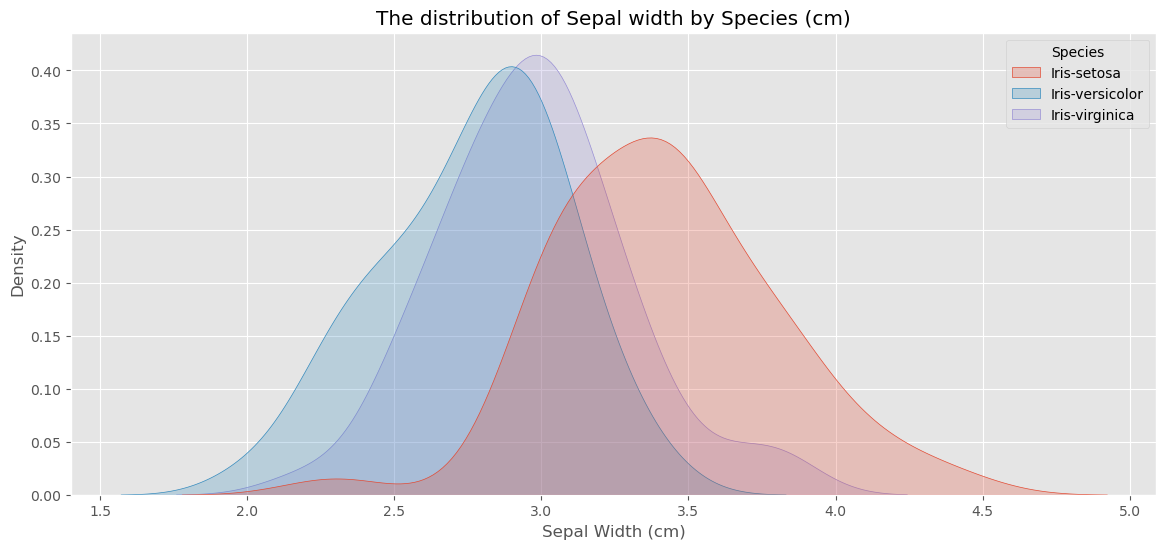

In [17]:
plt.figure(figsize=(14,6))
sns.kdeplot(data=df,x='SepalWidthCm',fill=True,hue='Species')
plt.xlabel('Sepal Width (cm)')
plt.title("The distribution of Sepal width by Species (cm)")
plt.show()

- We can notice based on the previous note that Iris Setosa have generally diffrent sepal mesurments( the average sepal width is 3.5cm) than versicolor and virginica species which are similar to each others (average sepal width of 3cm)

### Petal Length (cm) :

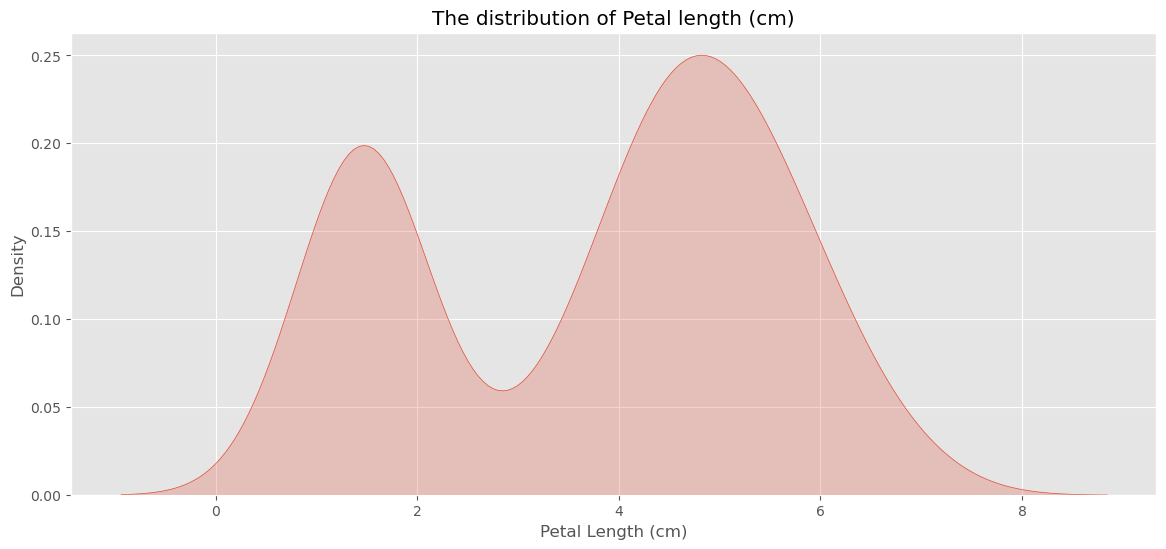

In [18]:
plt.figure(figsize=(14,6))
sns.kdeplot(data=df,x='PetalLengthCm',fill=True)
plt.xlabel('Petal Length (cm)')
plt.title("The distribution of Petal length (cm)")
plt.show()

- Petal length is in general either 1.5cm or 5cm cause we can see that there is two peaks , and we notice that it varies beween 0.5cm to 8cm (wide range)

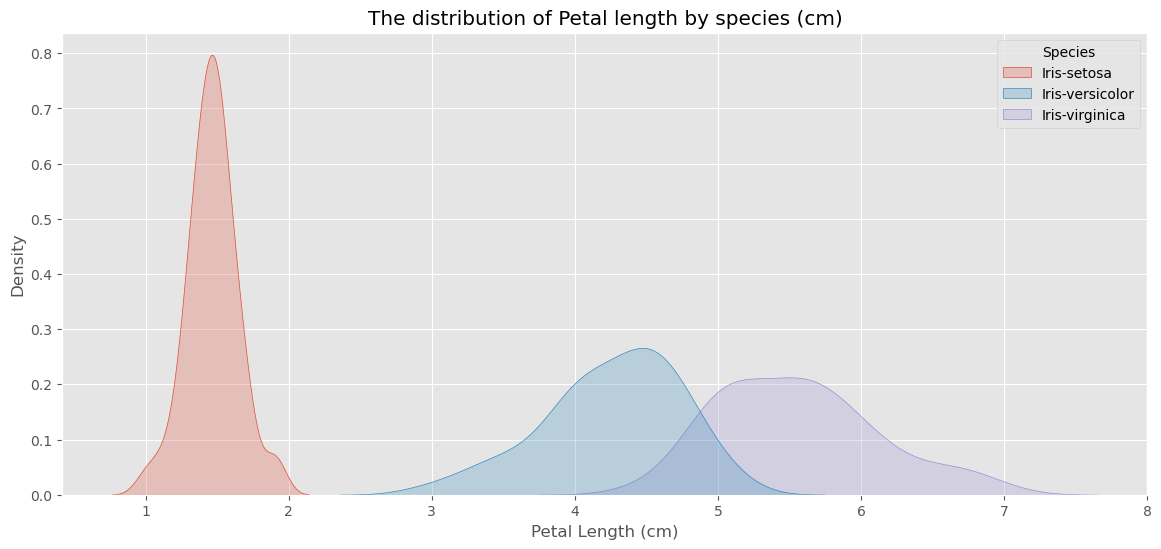

In [19]:
plt.figure(figsize=(14,6))
sns.kdeplot(data=df,x='PetalLengthCm',fill=True,hue='Species')
plt.xlabel('Petal Length (cm)')
plt.title("The distribution of Petal length by species (cm)")
plt.show()

- Iris Setosa have a very distinct petal length distribution between 1cm to 2cm and with an average of 1.5cm.
- The average petal length in Iris versicolor is 4.4 and it varies between 3cm and 5.5cm while close to it Iris verginica have an average of
  5.5cm and a range of 4cm to 7cm.

## Petal Width (cm):

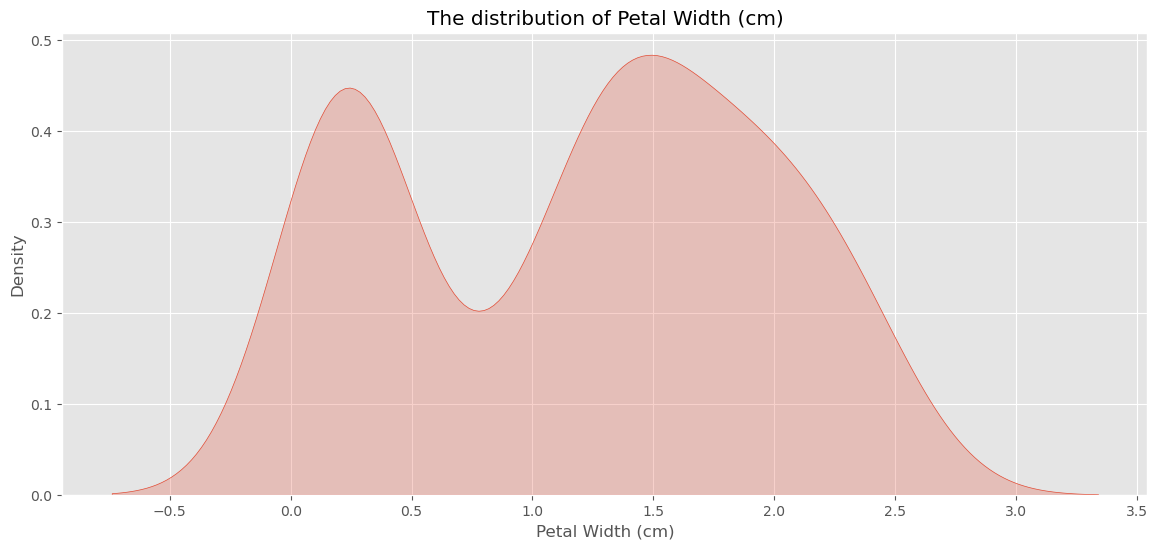

In [20]:
plt.figure(figsize=(14,6))
sns.kdeplot(data=df,x='PetalWidthCm',fill=True)
plt.xlabel('Petal Width (cm)')
plt.title("The distribution of Petal Width (cm)")
plt.show()

- Petal width is distributed like petal length with two peaks one in 0.3cm and the other is in 1.5cm and the range of the petal width is between 0.1cm and 3cm .

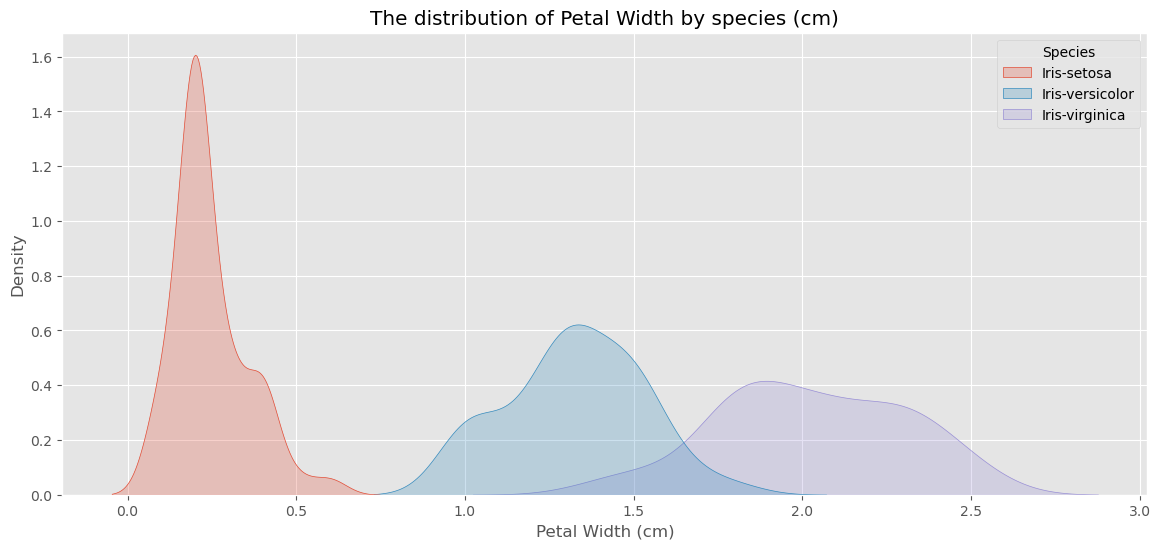

In [21]:
plt.figure(figsize=(14,6))
sns.kdeplot(data=df,x='PetalWidthCm',fill=True,hue='Species')
plt.xlabel('Petal Width (cm)')
plt.title("The distribution of Petal Width by species (cm)")
plt.show()

- Iris Setosa as usual is distinct from verginica and versicolor with a very smll petal width that varies between 0.1 and 0.6cm and with an average of 0.3cm.
- Iris verginica and versicolor are very close to each other in petal width (it ranges between 0.7cm and 2cm for versicolor and from 2cm to 2.7cm for virginica )

#### Summary
- Iris Setosa is generally distinct from verginica and versicolor .
- Iris verginica and versicolor have close measurments .
- Iris Setosa have a short sepal compared with others (about 5cm average) and a wide one with small petals (less than 2cm in length and 0.5cm in  width)
- Iris versicolor have medium measures with medium sepal and petals and verginica iris have close measures to it  but with a wider range of variety especially in petal measures.

## Data Preprocessing and model training :

In [22]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler


def creating_preprocessor(df,target,scale=False):
    '''Create a preprocessing pipline in which the steps of preprocessing both categorical and numerical columns are available
    args:
    df:
    the dataframe we want to preprocess its data , inorder to extract numerical and categorical columns from it .
    output:
    pipline that contains steps of preprocessing both categorical and numerical columns are available in the input dataframe
    '''
    df=df.drop(columns=[target])
    # first we must identify categorical columns from numerical columns :
    def split_categorical_from_numerical_cols(df):
        cols=df.columns
        num_cols=df.select_dtypes(exclude='str').columns
        cat_cols=[col for col in cols if col not in num_cols]
        return num_cols,cat_cols
        
    num_cols,cat_cols=split_categorical_from_numerical_cols(df)

    # identifying the preprocessing steps of numerical columns
    num_preprocessing=SimpleImputer(strategy='median')

    if scale:
        scaler=StandardScaler()
        num_preprocessing=Pipeline(steps=[
            ('imputing',SimpleImputer(strategy='median')),
            ('scaling features',scaler)
        ])
     
    #identifying preprocessing steps of categorical data
    cat_preprocessing=Pipeline(steps=[
        ('imputation',SimpleImputer(strategy='most_frequent')),
        ('encoding',OneHotEncoder(handle_unknown='ignore'))
    ])

    #combining numerical and categorical preprocessing in one pipline (preprocessor)
    preprocessor=ColumnTransformer(transformers=[
        ('num',num_preprocessing,num_cols),
        ('cat',cat_preprocessing,cat_cols)
    ])
    return preprocessor

In [23]:
from sklearn.ensemble import RandomForestClassifier

def randomForestClassification_model_creation():
    ''' Creates a classification model
    output:
        classification model
    '''
    model=RandomForestClassifier(random_state=42)
    return model

In [24]:
from sklearn.linear_model import LogisticRegression
def LogeisticRegression_model_creation():
    log_model=LogisticRegression()
    return log_model

In [25]:
from sklearn.neighbors import KNeighborsClassifier
def Knn_model_creation():
    knn_model=KNeighborsClassifier(n_neighbors=5)
    return knn_model

In [26]:
def pipline_creation(preprocessor,model):
    '''Creates a pipline that links the preprocessing logic with the model
    args:
        model : the machine learning model
        preprocessor : the preprocsessor that is a pipline that link the preprocessing steps 
    output:
        a pipline in which both the ml model and the preprocessor are combined
    '''
    pipline=Pipeline(steps=[
        ('Preprocessing',preprocessor),
        ('model',model)
    ])
    return pipline

In [27]:
df.columns

Index(['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='str')

In [35]:
def input_output(df):
    '''
    splitting the dataframe into input data and target 
    
    args:
        df: The dataframe 
    output:
        X: input data
        y: target data
    '''
    features=['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
    X=df[features]
    y=df['Species']
    return X,y

In [36]:
from sklearn.model_selection import train_test_split

def spliting_data(X,y):
    '''Spliting Data in the dataset into : training set and testing set
    args:
         X: input data
         y: target 
    output:
        train_X,test_X,train_y,test_y : training set with train_X,train_y and validation set with test_X,test_y
    '''
    train_X,test_X,train_y,test_y=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
    return train_X,test_X,train_y,test_y

In [37]:
def train(df,model_creation):
    '''
    This function splits the data , creates the pipline and fit it with training data
    args:
        df: the dataframe that will be splitted into training set and testing set
        model_creation: model creation function that creates a specific classification model
    output:
        pipline: trained model linked to the preprocessing logic using piplines
    '''
    # splitting the dataframe into X and y
    X,y=input_output(df)
    # splitting the data
    train_X,test_X,train_y,test_y=spliting_data(X,y)
    
    # creating the preprocessor
    if ( model_creation==LogeisticRegression_model_creation ) or ( model_creation==Knn_model_creation ) :
        preprocessor=creating_preprocessor(df,'Species',True)
    else:
        preprocessor=creating_preprocessor(df,'Species')

    # model creation 
    model=model_creation()
    # pipline creation 
    pipline=pipline_creation(preprocessor,model)

    # fitting the model and the preprocessor 
    pipline.fit(train_X,train_y)

    return pipline

In [40]:
log_pip=train(df,LogeisticRegression_model_creation)

In [41]:
rand_forest_pip=train(df,randomForestClassification_model_creation)

In [42]:
knn_pip=train(df,Knn_model_creation)

In [43]:
# saving the trained model+preprocessor 
import joblib
def save_model(df,model_creation):
    pipline=train(df,model_creation)
    joblib.dump(pipline,'piplines/pipline.pkl')
    print('The pipline was saved successfully')

In [44]:
from sklearn.model_selection import cross_val_score

# evaluating the model using cross validation since the iris dataset is too small
def cross_validation(model,X,y):
    scores=cross_val_score(model,X,y,cv=5,scoring='f1_macro')
    return scores.mean()

In [47]:
# evaluating the logistic regression model 
X,y=input_output(df)
cross_validation(log_pip,X,y)

np.float64(0.9597984861142755)

In [48]:
# evaluation the random forest classification model 
cross_validation(rand_forest_pip,X,y)

np.float64(0.9664818612187034)

In [49]:
# evaluating knn model
cross_validation(knn_pip,X,y)

np.float64(0.9598319029897976)

In [50]:
# predicting using the model 
def predict(new_data):
    model=joblib.load('piplines/pipline.pkl')
    return model.predict(new_data)

In [51]:
# predicting the probability of each class 
def predict_proba(new_data):
    model=joblib.load('piplines/pipline.pkl')
    return model.predict_proba(new_data)